# Supermarket Sales Analysis

## Problem Statement
Analyzed supermarket sales data to understand branch performance, 
popular product lines, customer payment preferences, and ratings.

## Dataset
- Total Records: 31
- Branches: A, B, C
- Cities: Yangon, Mandalay, Naypyitaw

## Goals
- Compare sales across branches
- Identify best selling product lines
- Analyze customer payment methods
- Understand gender-wise rating pattern
- Find relation between unit price and total sales

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [2]:
df = pd.read_csv("supermarket_sales.csv")

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Unnamed: 17,city
0,750-67-8428,A,nagpur,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01-05-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,NaN,nagpur
1,226-31-3081,C,lukhnow,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03-08-2019,10:29,Cash,76.40,4.761905,3.8200,9.6,NaN,NaN
2,631-41-3108,A,surat,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4,NaN,NaN
3,123-19-1176,A,jaipur,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4,NaN,NaN
4,315-22-5665,C,nagpur,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0,NaN,NaN


In [4]:
print(df.shape)
print(df.info())

(31, 19)
<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               31 non-null     str    
 1   Branch                   31 non-null     str    
 2   City                     31 non-null     str    
 3   Customer type            31 non-null     str    
 4   Gender                   31 non-null     str    
 5   Product line             31 non-null     str    
 6   Unit price               31 non-null     float64
 7   Quantity                 31 non-null     int64  
 8   Tax 5%                   31 non-null     float64
 9   Total                    31 non-null     float64
 10  Date                     31 non-null     str    
 11  Time                     31 non-null     str    
 12  Payment                  31 non-null     str    
 13  cogs                     31 non-null     float64
 14  gross margin percentage  31 no

In [5]:
df.isnull().sum()

Invoice ID                  0
Branch                      0
City                        0
Customer type               0
Gender                      0
Product line                0
Unit price                  0
Quantity                    0
Tax 5%                      0
Total                       0
Date                        0
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
Unnamed: 17                31
city                       30
dtype: int64

In [6]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating,Unnamed: 17
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,0.0
mean,61.586452,5.612903,16.907871,355.065290,338.125161,4.761905,16.907871,7.329032,NaN
std,20.599899,2.216264,8.289731,174.084344,165.819667,0.000000,8.289731,1.400522,NaN
min,15.280000,2.000000,3.626000,76.146000,72.520000,4.761905,3.626000,4.100000,NaN
25%,45.500000,4.000000,11.240500,236.050500,224.310000,4.761905,11.240500,6.200000,NaN
50%,61.230000,6.000000,16.215500,340.525500,324.310000,4.761905,16.215500,7.400000,NaN
75%,77.725000,7.000000,23.156500,486.286500,463.130000,4.761905,23.156500,8.350000,NaN
max,95.430000,10.000000,36.780000,772.380000,735.600000,4.761905,36.780000,9.600000,NaN


In [7]:
df['Branch'].value_counts()

Branch
A    12
C    11
B     8
Name: count, dtype: int64

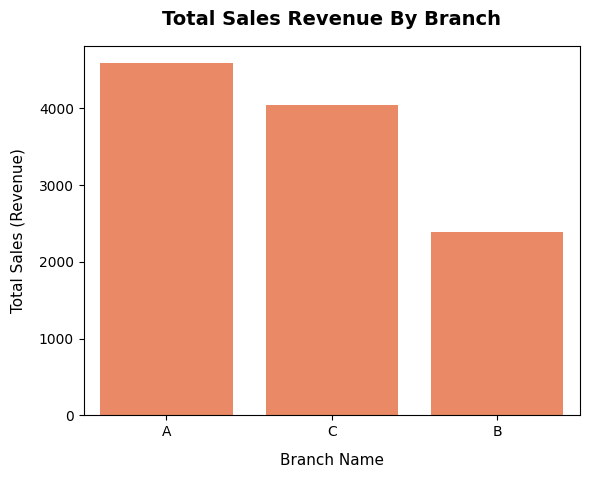

In [12]:
sns.barplot(x='Branch',y='Total', data= df, estimator=sum, errorbar=None, color='coral')
plt.title("Total Sales Revenue By Branch",fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Branch Name", fontsize=11, labelpad=10)
plt.ylabel("Total Sales (Revenue)", fontsize=11, labelpad=10)
plt.show()

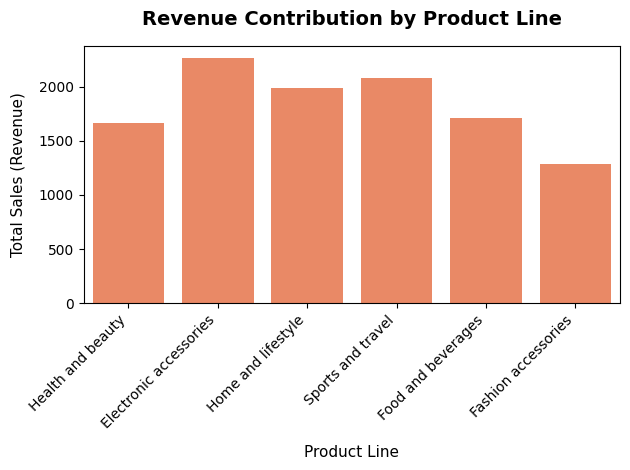

In [15]:
sns.barplot(x='Product line',y='Total', data= df, estimator=sum, errorbar=None, color='coral')
plt.title("Revenue Contribution by Product Line",fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Product Line", fontsize=11, labelpad=10)
plt.ylabel("Total Sales (Revenue)", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

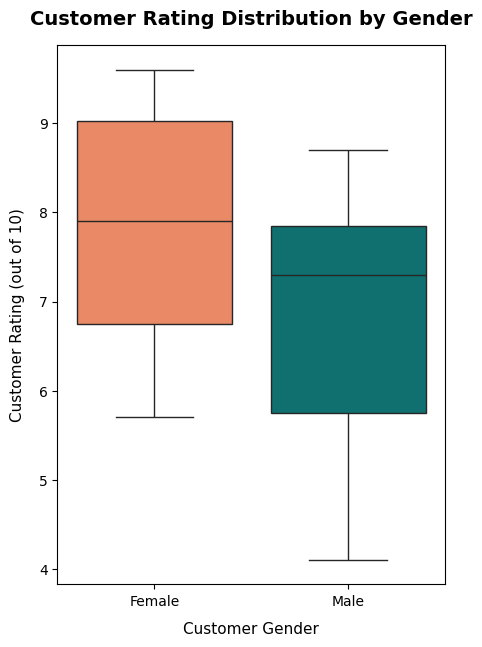

In [22]:
plt.figure(figsize=(5,7))
custom_colors = {"Female":"coral" , "Male":"teal"}

sns.boxplot(x = 'Gender', y ='Rating', data=df, hue = 'Gender', palette=custom_colors)
plt.title("Customer Rating Distribution by Gender", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Customer Gender" , fontsize=11 ,labelpad=10)
plt.ylabel("Customer Rating (out of 10)",  fontsize=11 ,labelpad=10)
plt.show()
                 

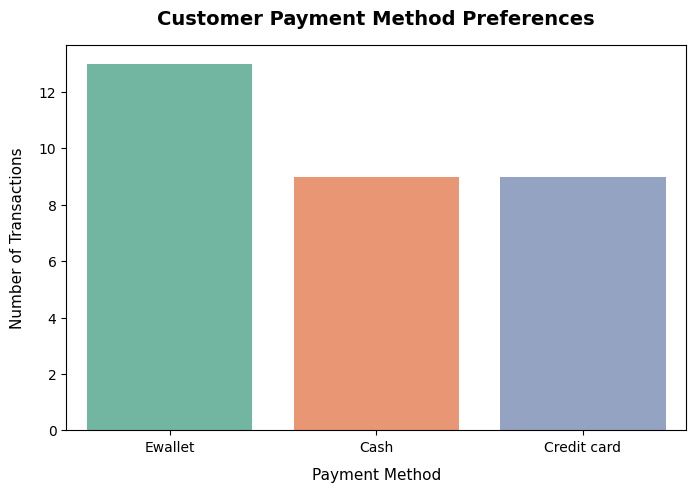

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="Payment" , data=df, hue='Payment', palette='Set2' , legend=False)
plt.title("Customer Payment Method Preferences", fontsize=14 , fontweight='bold', pad=15)
plt.xlabel("Payment Method", fontsize=11, labelpad=10)
plt.ylabel("Number of Transactions",fontsize=11, labelpad=10)
plt.show()

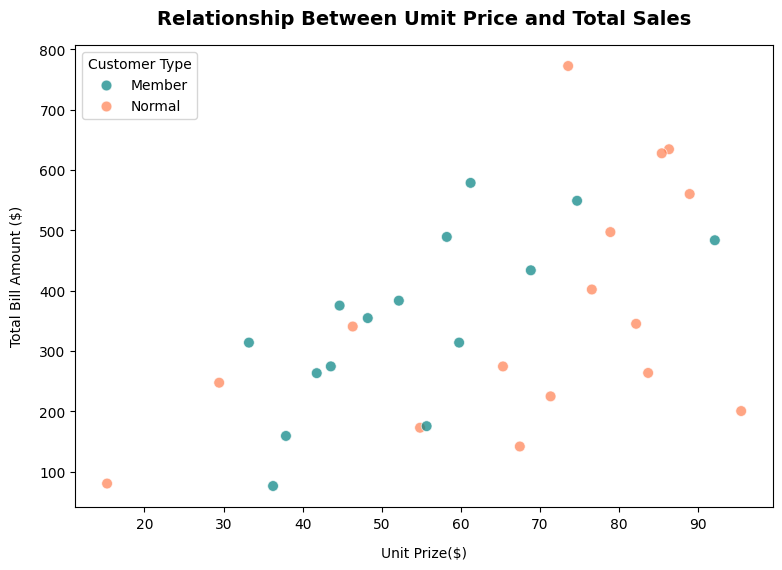

In [28]:
plt.figure(figsize=(9,6))
sns.scatterplot(x="Unit price", y="Total", data=df, hue="Customer type",
                palette={'Member' :'teal', 'Normal' : 'coral'},alpha=0.7,s=60)
plt.title("Relationship Between Umit Price and Total Sales",fontsize=14,fontweight='bold', pad=15)
plt.xlabel("Unit Prize($)", fontsize=10,labelpad=11)
plt.ylabel("Total Bill Amount ($)",fontsize=10,labelpad=11)
plt.legend(title="Customer Type", loc="upper left")
plt.show()
            

## Conclusion
- Branch A had the highest average sales
- Sports and Travel was the top selling product line
- Ewallet was the most preferred payment method (13 out of 31)
- Female customers gave higher and more consistent ratings
- Positive correlation found between Unit Price and Total Sales